# 1. Entendimento do negócio

Nesta primeira etapa, o objetivo é exercitar o pensamento analítico, focando no entendimento do problema de negócio.




### ● Qual problema de negócio está sendo resolvido?

**Resposta:**  
O problema está na dificuldade de entender, antes do fim da jornada, quais fatores impactam a satisfação do cliente. Atualmente, o NPS é coletado apenas após a conclusão da compra, o que impede a empresa de agir no momento certo.

Dessa forma, o objetivo é utilizar os dados disponíveis para identificar problemas de forma antecipada e melhorar a experiência do cliente de maneira proativa.

---

### ● Por que o NPS é importante para um e-commerce?

**Resposta:**  
O NPS mede a satisfação e a lealdade do cliente. Em um e-commerce, isso é essencial, pois o cliente pode mudar de loja com facilidade.

Um NPS alto indica maior chance de recompra e recomendação, enquanto um NPS baixo aponta problemas na experiência do cliente.

Dessa forma, o NPS ajuda a entender se a operação está realmente gerando valor para o cliente.

---

### ● Quais áreas poderiam se beneficiar desses insights?

**Resposta:**

- **Logística:** identificar atrasos e problemas na entrega  
- **Atendimento:** melhorar tempo de resposta e resolução de problemas  
- **Produto:** avaliar qualidade e expectativa vs. realidade  
- **Pricing:** entender se o preço está alinhado com o valor percebido  
- **Experiência do cliente / estratégia:** priorizar melhorias na jornada  

---

### ● Como o NPS impacta a recompra, boca a boca e market share em e-commerce?

**Resposta:**  
O NPS impacta diretamente a recompra, pois clientes satisfeitos (promotores) tendem a comprar novamente, enquanto clientes insatisfeitos (detratores) dificilmente retornam.

No boca a boca, clientes com NPS alto costumam recomendar a marca para outras pessoas, gerando crescimento orgânico. Já clientes com NPS baixo podem compartilhar experiências negativas, prejudicando a imagem da empresa.

Em relação ao market share, um NPS elevado contribui para o aumento da base de clientes e fidelização, ajudando a empresa a ganhar espaço no mercado. Por outro lado, um NPS baixo pode resultar em perda de clientes para concorrentes.

---

### ● Quais indicadores de mercado poderiam complementar essa análise?

**Resposta:**

- **Benchmark de NPS:** comparar o desempenho da empresa com o mercado  
- **SLA logístico:** medir prazos de entrega e eficiência operacional  
- **Taxa de recompra:** entender o comportamento de fidelização  
- **Churn (cancelamento):** identificar perda de clientes  
- **Análise da concorrência:** comparar preços, prazos e experiência oferecida  

# 2. Definição da Target

Nesta etapa, o objetivo é definir a variável alvo do problema de negócio, com foco no entendimento conceitual.




### ● Qual variável representa a satisfação do cliente?

**Resposta:**  
A variável que representa a satisfação do cliente é o **nps_score**.

---

### ● Por que ela foi escolhida?

**Resposta:**  
O **nps_score** foi escolhido porque é um indicador direto da satisfação e lealdade do cliente. Ele reflete a percepção do cliente sobre toda a experiência de compra, permitindo classificá-lo como promotor, neutro ou detrator.

---

### ● Em que momento da jornada essa informação é coletada?

**Resposta:**  
Essa informação é coletada ao final da jornada de compra, após a entrega do pedido e a conclusão da experiência do cliente.

---

### ● Existe algum risco de usar essa variável de forma inadequada?

**Resposta:**  
Sim. O principal risco é utilizar o NPS de forma isolada, sem considerar o contexto operacional que gerou aquela experiência.

Como ele é coletado apenas ao final da jornada, representa um resultado já consolidado, não permitindo ações preventivas. Além disso, pode ser influenciado por fatores pontuais ou externos, o que pode levar a interpretações incorretas se não for analisado junto com outras variáveis.

# 3. Análise Exploratória dos Dados: Explorando a Satisfação do Cliente com NPS

Neste notebook, vamos explorar a satisfação dos clientes por meio do **NPS (Net Promoter Score)** a partir de uma perspectiva analítica e narrativa. Nosso objetivo não é apenas apresentar números, mas **construir uma história com base em evidências, visualizações e interpretações** que permitam compreender melhor a experiência dos clientes.

Ao longo da análise, buscamos identificar **quais fatores influenciam a satisfação**, além de compreender padrões de comportamento dos clientes em relação ao serviço ou produto analisado.

---

## O que é NPS?

O **Net Promoter Score (NPS)** é uma métrica amplamente utilizada para medir **satisfação e lealdade do cliente**. Ela se baseia na pergunta:

> *"Em uma escala de 0 a 10, o quanto você recomendaria nossa empresa ou serviço para um amigo ou colega?"*

A partir dessa avaliação, os clientes são classificados em três categorias:

- **Detratores (0 a <6):** clientes insatisfeitos ou frustrados, com maior probabilidade de gerar feedback negativo ou abandonar o serviço.
- **Neutros (6 a <8):** clientes relativamente satisfeitos, mas que não demonstram forte lealdade à marca.
- **Promotores (8 a 10):** clientes muito satisfeitos, com maior probabilidade de recomendar a empresa.

---

## Objetivo da análise

Nosso objetivo é **entender os fatores que impactam a experiência do cliente**, buscando padrões que expliquem níveis diferentes de satisfação.

Ao longo da análise, vamos responder principalmente às seguintes perguntas:

- **Quais fatores parecem mais críticos para a satisfação do cliente?**
- **O que mais gera detratores?**
- **Existe algum “ponto de ruptura” na experiência do cliente?**
- **Que tipo de cliente tende a ter NPS mais alto ou mais baixo?**

---


### 3.1. Importação de bibliotecas e configurações iniciais

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")
sns.set(style="whitegrid")

plt.rcParams["figure.figsize"] = (8,5)
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 11

## 3.2. Contexto e carregamento dos dados

Antes de iniciar a análise, é importante compreender **a estrutura e a qualidade dos dados disponíveis**. Nesta etapa, iremos carregar a base de dados e realizar uma primeira inspeção para entender melhor suas características.

Serão analisados aspectos como:

- as **colunas presentes no dataset** e o significado de cada variável;
- o **tamanho da base de dados** (quantidade de linhas e colunas);
- a existência de **valores nulos ou ausentes**;
- a presença de **registros duplicados**;
- e a **tradução ou padronização dos nomes das colunas**, quando necessário, para facilitar a interpretação durante a análise.

Essa exploração inicial é essencial para garantir que os dados estejam organizados e adequados para as próximas etapas da análise.

In [10]:
# Importando a Base de Dados e Lendo os 5 primeiros dados
df = pd.read_csv('../data/NPS.csv')
df.head()

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9


In [11]:
# Verificando as informações de cada coluna do dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customer_id                2500 non-null   int64  
 1   customer_age               2500 non-null   int64  
 2   customer_region            2500 non-null   str    
 3   customer_tenure_months     2500 non-null   int64  
 4   order_id                   2500 non-null   int64  
 5   order_value                2500 non-null   float64
 6   items_quantity             2500 non-null   int64  
 7   discount_value             2500 non-null   float64
 8   payment_installments       2500 non-null   int64  
 9   delivery_time_days         2500 non-null   int64  
 10  delivery_delay_days        2500 non-null   int64  
 11  freight_value              2500 non-null   float64
 12  delivery_attempts          2500 non-null   int64  
 13  customer_service_contacts  2500 non-null   int64  
 14  res

In [12]:
# Verificando o tamanho do dataset (linhas , colunas)
print(f'Tamanho do Dataset (linhas, colunas) : {df.shape}')

Tamanho do Dataset (linhas, colunas) : (2500, 19)


In [13]:
# Pegando a somatória dos dados nulos por coluna
print(f'Total de dados nulos no Dataset : {df.isnull().sum().sum()}')

Total de dados nulos no Dataset : 0


In [14]:
# Pegando os dados duplicados
print(f'Total de dados duplicados no Dataset : {df.duplicated().sum()}')

Total de dados duplicados no Dataset : 0


In [15]:
# Fazendo a tradução das colunas para um melhor entendimento
df = df[['customer_age', 'customer_region','customer_tenure_months', 'order_value', 'items_quantity',
       'discount_value', 'payment_installments', 'delivery_time_days','delivery_delay_days', 'freight_value', 'delivery_attempts',
       'customer_service_contacts', 'resolution_time_days', 'nps_score','repeat_purchase_30d', 'complaints_count', 'csat_internal_score']]

df.columns = ['idade_cliente', 'regiao_cliente', 'tempo_cliente_meses', 'valor_pedido', 'quantidade_itens','valor_desconto', 'parcelas_pagamento',
                  'tempo_entrega_dias', 'atraso_entrega_dias', 'valor_frete','tentativas_entrega', 'contatos_atendimento', 'tempo_resolucao_dias',
                  'nps', 'recompra_30_dias', 'numero_reclamacoes', 'pontuacao_csat_interno']

In [16]:
df.head()

,idade_cliente,regiao_cliente,tempo_cliente_meses,valor_pedido,quantidade_itens,valor_desconto,parcelas_pagamento,tempo_entrega_dias,atraso_entrega_dias,valor_frete,tentativas_entrega,contatos_atendimento,tempo_resolucao_dias,nps,recompra_30_dias,numero_reclamacoes,pontuacao_csat_interno
0,63,Nordeste,14,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5
1,20,Sul,1,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0
2,46,Nordeste,111,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5
3,52,Centro-Oeste,117,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3
4,56,Norte,50,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9


## 3.3. Panorama geral do NPS

Nesta etapa, será apresentado um **panorama geral da distribuição do NPS** na base de dados. Para isso, serão analisadas as **estatísticas descritivas** da variável NPS, como média, mediana, valores mínimos e máximos, além da dispersão dos dados.

Também serão utilizadas visualizações gráficas, como **histograma e boxplot**, que permitem observar como as avaliações estão distribuídas, identificar possíveis concentrações de notas e detectar a presença de **outliers ou assimetrias** na distribuição do NPS.

Essa análise inicial ajuda a compreender **o comportamento geral da satisfação dos clientes** antes de avançar para análises mais detalhadas.

In [17]:
# Verificando a estatística descritiva do dataframe
df.describe().round(2)

,idade_cliente,tempo_cliente_meses,valor_pedido,quantidade_itens,valor_desconto,parcelas_pagamento,tempo_entrega_dias,atraso_entrega_dias,valor_frete,tentativas_entrega,contatos_atendimento,tempo_resolucao_dias,nps,recompra_30_dias,numero_reclamacoes,pontuacao_csat_interno
count,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00
mean,43.40,61.32,434.26,3.47,29.75,6.00,8.02,2.19,38.22,2.01,1.52,5.49,4.38,0.09,4.15,2.94
std,14.89,34.48,289.77,1.69,29.23,3.16,3.77,1.45,12.08,0.82,1.23,3.46,2.51,0.28,1.78,2.38
min,18.00,1.00,7.76,1.00,0.02,1.00,2.00,0.00,2.62,1.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,31.00,31.00,220.24,2.00,8.88,3.00,5.00,1.00,29.93,1.00,1.00,2.00,2.60,0.00,3.00,0.70
50%,43.00,62.00,375.52,3.00,20.94,6.00,8.00,2.00,38.50,2.00,1.00,6.00,4.40,0.00,4.00,2.80
75%,56.00,91.00,577.29,5.00,40.83,9.00,11.00,3.00,46.27,3.00,2.00,8.00,6.10,0.00,5.00,4.80
max,69.00,119.00,1983.81,6.00,230.33,11.00,14.00,8.00,76.13,3.00,7.00,11.00,10.00,1.00,11.00,10.00


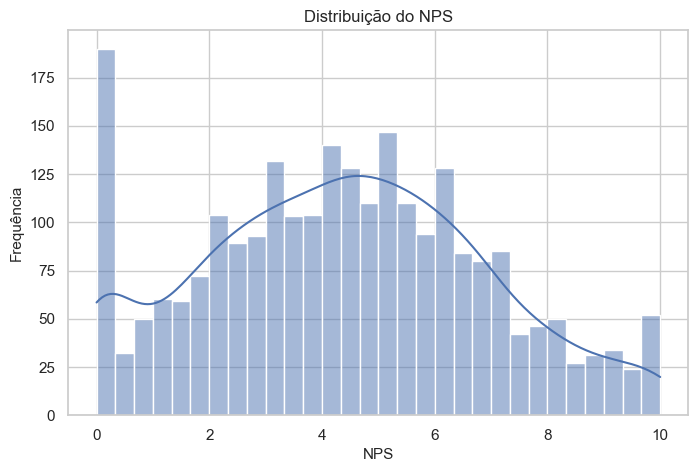

In [18]:
# Visualizando o Histograma do NPS - visualizando suas frequências
sns.histplot(data=df, x='nps', bins=30, kde=True)
plt.title('Distribuição do NPS')
plt.xlabel('NPS')
plt.ylabel('Frequência')
plt.show()

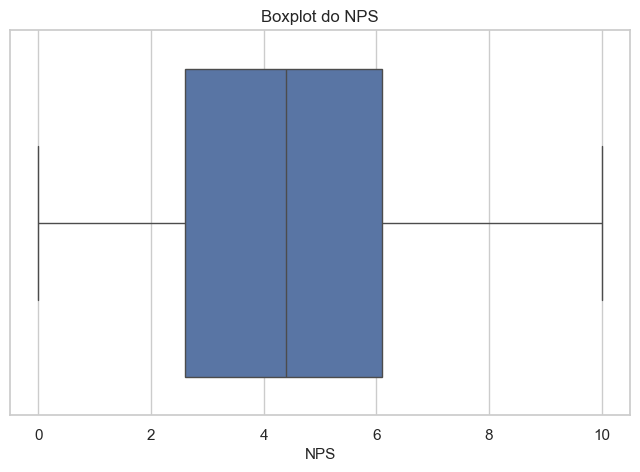

In [19]:
# Visualizando o Boxplot
sns.boxplot(data=df, x='nps')
plt.title('Boxplot do NPS')
plt.xlabel('NPS')
plt.show()

In [20]:
df['nps'].agg(['mean', 'median', 'min','max']).round(2)

mean       4.38
median     4.40
min        0.00
max       10.00
Name: nps, dtype: float64

## 3.4. Classificação do NPS

Nesta etapa, as avaliações de NPS serão classificadas em três grupos principais, conforme a metodologia tradicional da métrica:

- **Detratores:** notas de 0 a < 6  
- **Neutros:** notas de 6 a < 8  
- **Promotores:** notas de 8 a 10  

Após essa classificação, será analisada a **distribuição de cada grupo** na base de dados. Para isso, serão apresentadas visualizações que mostram:

- a **quantidade de clientes em cada categoria** (contagem);
- a **média das notas de NPS dentro de cada classificação**.

Essa etapa permite entender melhor **como os clientes se distribuem em termos de satisfação**, além de identificar se há predominância de promotores, neutros ou detratores na base analisada.

In [21]:
df['classe'] = pd.cut(df['nps'],
                      bins=[-1., 6., 8., np.inf],
                      labels=['Detratores', 'Neutros', 'Promotores'])

df.head()

,idade_cliente,regiao_cliente,tempo_cliente_meses,valor_pedido,quantidade_itens,valor_desconto,parcelas_pagamento,tempo_entrega_dias,atraso_entrega_dias,valor_frete,tentativas_entrega,contatos_atendimento,tempo_resolucao_dias,nps,recompra_30_dias,numero_reclamacoes,pontuacao_csat_interno,classe
0,63,Nordeste,14,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5,Neutros
1,20,Sul,1,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0,Detratores
2,46,Nordeste,111,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5,Detratores
3,52,Centro-Oeste,117,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3,Detratores
4,56,Norte,50,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9,Neutros


In [22]:
# Verificando a contagem de cada classificador
df['classe'].value_counts().sort_values()

classe
Promotores     201
Neutros        448
Detratores    1851
Name: count, dtype: int64

In [23]:
# Verificando a média de cada classificador
media_nps = df.groupby('classe')['nps'].mean().sort_values().round(2)
media_nps

classe
Detratores    3.26
Neutros       6.89
Promotores    9.10
Name: nps, dtype: float64

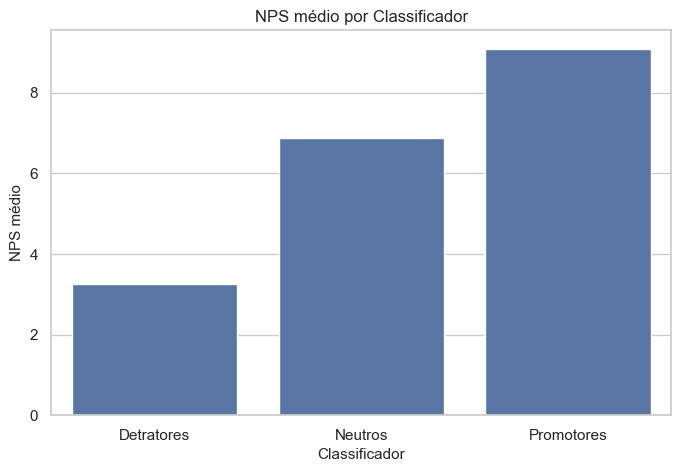

In [24]:
sns.barplot(x=media_nps.index, y=media_nps.values)
plt.title('NPS médio por Classificador')
plt.xlabel('Classificador')
plt.ylabel('NPS médio')
plt.show()

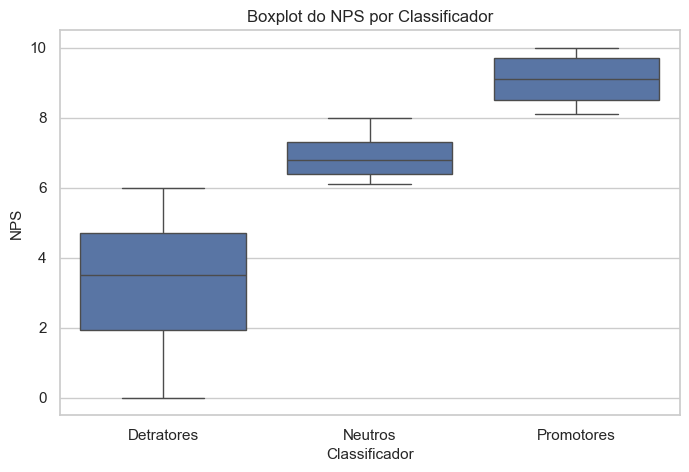

In [25]:
sns.boxplot(data=df, x='classe', y='nps')
plt.title('Boxplot do NPS por Classificador')
plt.xlabel('Classificador')
plt.ylabel('NPS')
plt.show()

## 3.5. Fatores mais críticos para a satisfação

A partir das análises gráficas exploratórias, foi possível identificar alguns fatores que parecem estar mais associados às variações no nível de satisfação dos clientes, representado pelo **NPS**.

Entre as variáveis analisadas, destacam-se principalmente **número de reclamações**, **atraso na entrega** e **score interno de satisfação**, que apresentam diferenças mais evidentes entre clientes com avaliações mais altas e mais baixas de NPS.

De modo geral, clientes com **menos reclamações**, **menor atraso nas entregas** e **maiores valores no score interno de satisfação** tendem a apresentar níveis mais elevados de NPS. Por outro lado, quando esses fatores apresentam piores valores, observa-se maior presença de avaliações mais baixas.

As demais variáveis analisadas mostraram uma distribuição mais equilibrada entre os diferentes níveis de NPS, sugerindo menor influência direta na variação da satisfação dos clientes.

Dessa forma, esses três fatores se destacam como os principais elementos associados às diferenças nos níveis de satisfação observados no conjunto de dados.

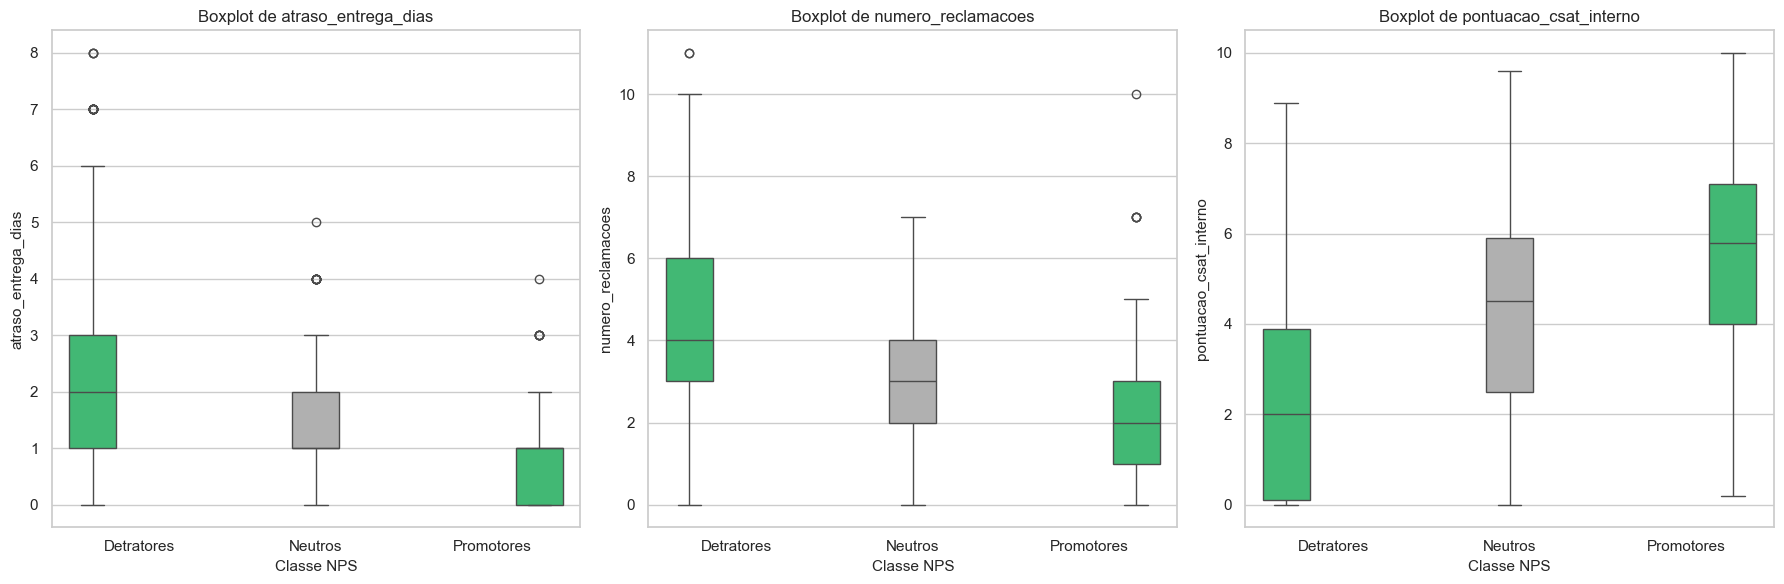

In [26]:
# Visualizando o Boxplot e fazendo a comparação dos fatores mais críticos
fig, ax = plt.subplots(1, 3, figsize=(18,6))

colunas = ['atraso_entrega_dias', 'numero_reclamacoes', 'pontuacao_csat_interno']

palette = {
    'Detratores': '#2ecc71',
    'Neutros': '#b0b0b0',
    'Promotores': '#2ecc71'
}

for i, col in enumerate(colunas):
    order = ['Detratores', 'Neutros', 'Promotores']
    sns.boxplot(data=df, x='classe', y=col, order=order, ax=ax[i], palette=palette, legend=False, hue='classe')
    ax[i].set_title(f'Boxplot de {col}')
    ax[i].set_xlabel('Classe NPS')
    ax[i].set_ylabel(col)

plt.tight_layout()
plt.show()

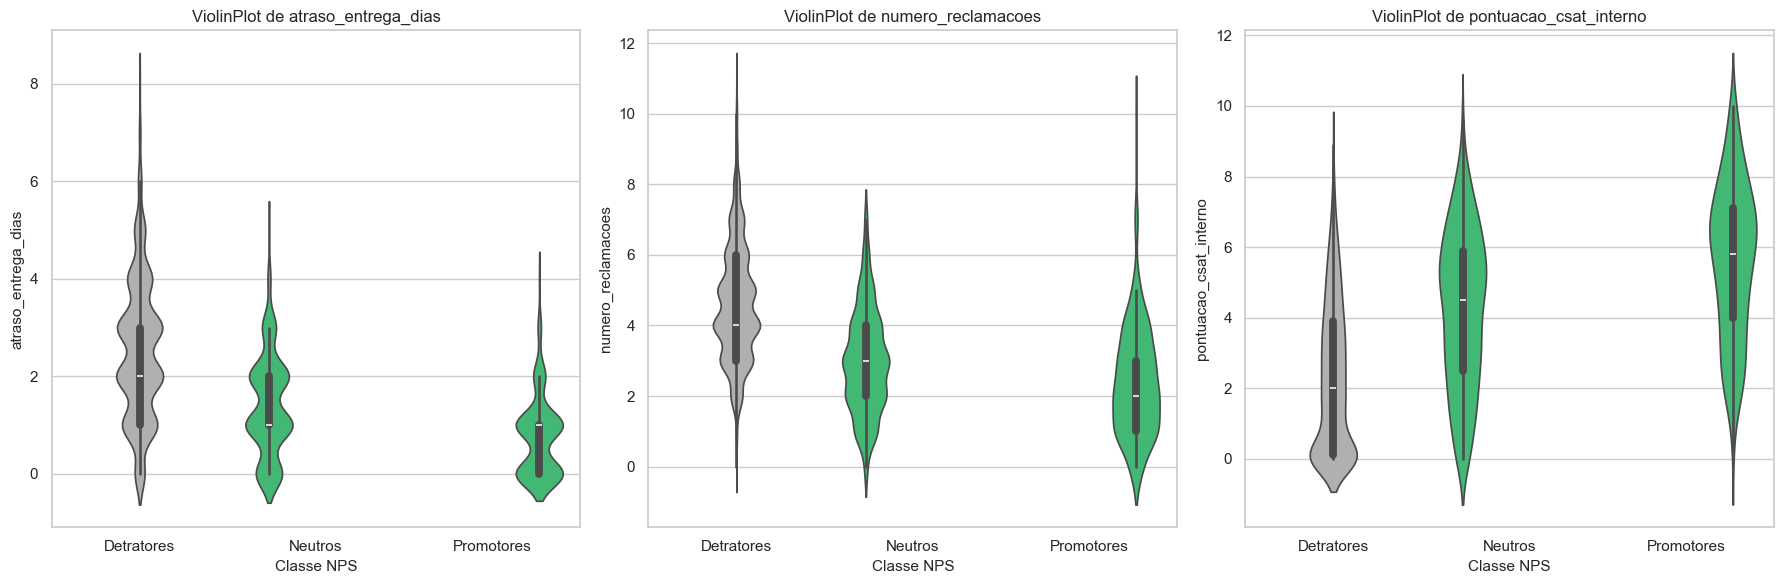

In [27]:
# Visualizando o ViolinPlot e fazendo a comparação dos fatores mais críticos
fig, ax = plt.subplots(1, 3, figsize=(18,6))

colunas = ['atraso_entrega_dias', 'numero_reclamacoes', 'pontuacao_csat_interno']

palette = {
    'Detratores': '#2ecc71',
    'Neutros': '#b0b0b0',
    'Promotores': '#2ecc71'
}

for i, col in enumerate(colunas):
    order = ['Detratores', 'Neutros', 'Promotores']
    sns.violinplot(data=df, x='classe', y=col, order=order, ax=ax[i], palette=palette, hue='classe')
    ax[i].set_title(f'ViolinPlot de {col}')
    ax[i].set_xlabel('Classe NPS')
    ax[i].set_ylabel(col)

plt.tight_layout()
plt.show()

## 3.6. Explorando o que mais gera detratores

A análise dos gráficos indica alguns fatores que parecem estar associados a avaliações mais baixas de NPS, caracterizando clientes classificados como **Detratores**.

Observa-se que clientes com **maior número de reclamações**, **maiores atrasos na entrega** e **menores níveis de satisfação interna (CSAT)** tendem a apresentar notas mais baixas na avaliação do serviço. Esses padrões sugerem que falhas operacionais e experiências negativas ao longo da jornada do cliente podem influenciar diretamente a probabilidade de um cliente se tornar detrator.

Dessa forma, problemas recorrentes, atrasos na entrega e uma percepção geral de baixa qualidade no atendimento aparecem como fatores relevantes para explicar níveis mais baixos de satisfação.

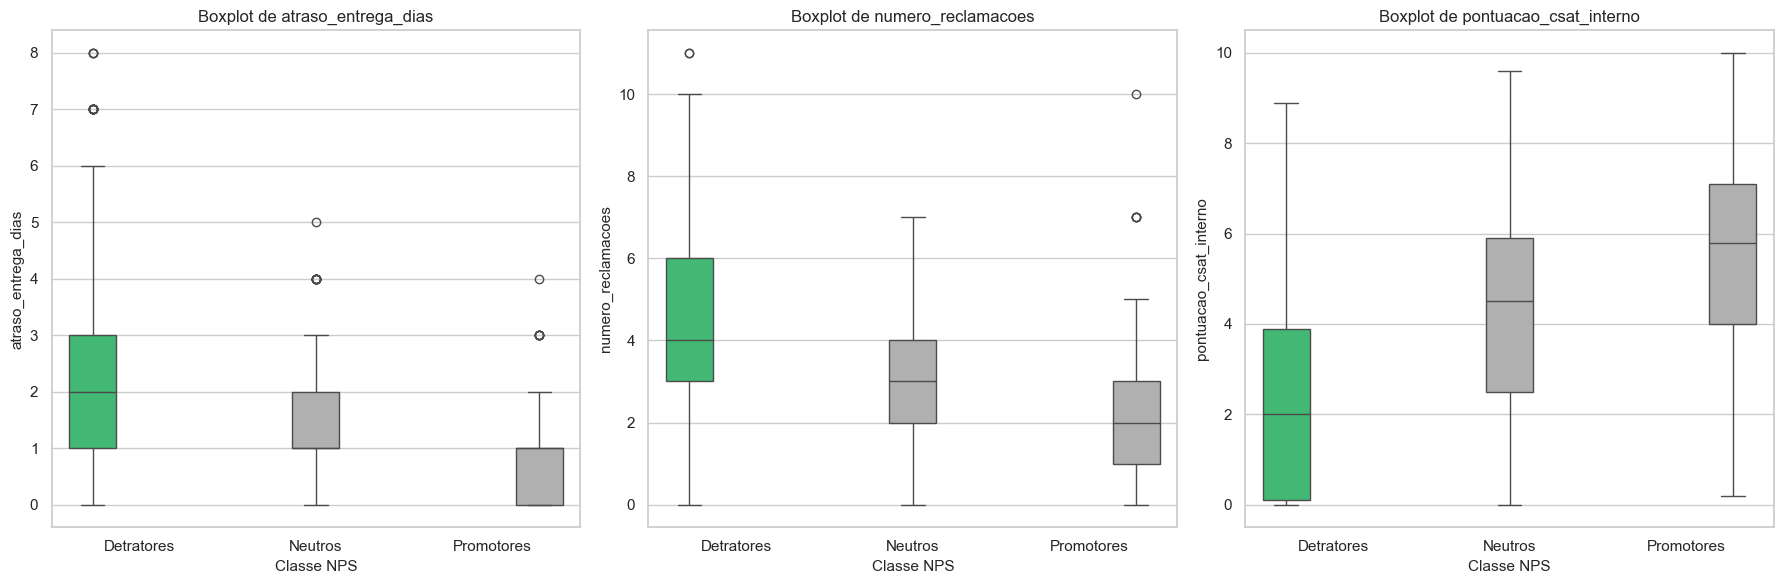

In [28]:
# Visualizando o Boxplot e fazendo a comparação dos Detratores
fig, ax = plt.subplots(1, 3, figsize=(18,6))

colunas = ['atraso_entrega_dias', 'numero_reclamacoes', 'pontuacao_csat_interno']

palette = {
    'Detratores': '#2ecc71',
    'Neutros': '#b0b0b0',
    'Promotores': '#b0b0b0'
}

for i, col in enumerate(colunas):
    order = ['Detratores', 'Neutros', 'Promotores']
    sns.boxplot(data=df, x='classe', y=col, order=order, ax=ax[i], palette=palette, legend=False, hue='classe')
    ax[i].set_title(f'Boxplot de {col}')
    ax[i].set_xlabel('Classe NPS')
    ax[i].set_ylabel(col)

plt.tight_layout()
plt.show()

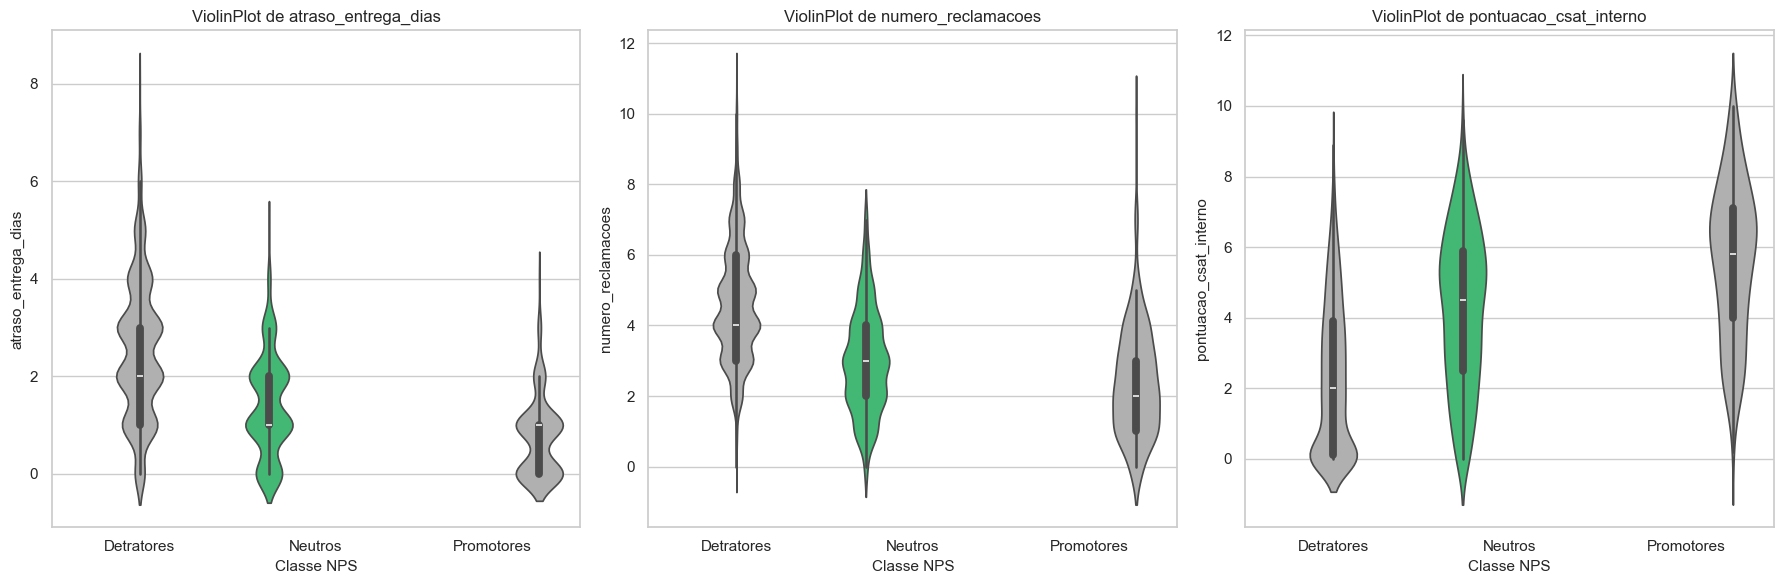

In [29]:
# Visualizando o ViolinPlot e fazendo a comparação dos Detratores
fig, ax = plt.subplots(1, 3, figsize=(18,6))

colunas = ['atraso_entrega_dias', 'numero_reclamacoes', 'pontuacao_csat_interno']

palette = {
    'Detratores': '#2ecc71',
    'Neutros': '#b0b0b0',
    'Promotores': '#b0b0b0'
}

for i, col in enumerate(colunas):
    order = ['Detratores', 'Neutros', 'Promotores']
    sns.violinplot(data=df, x='classe', y=col, order=order, ax=ax[i], palette=palette, hue='classe')
    ax[i].set_title(f'ViolinPlot de {col}')
    ax[i].set_xlabel('Classe NPS')
    ax[i].set_ylabel(col)

plt.tight_layout()
plt.show()

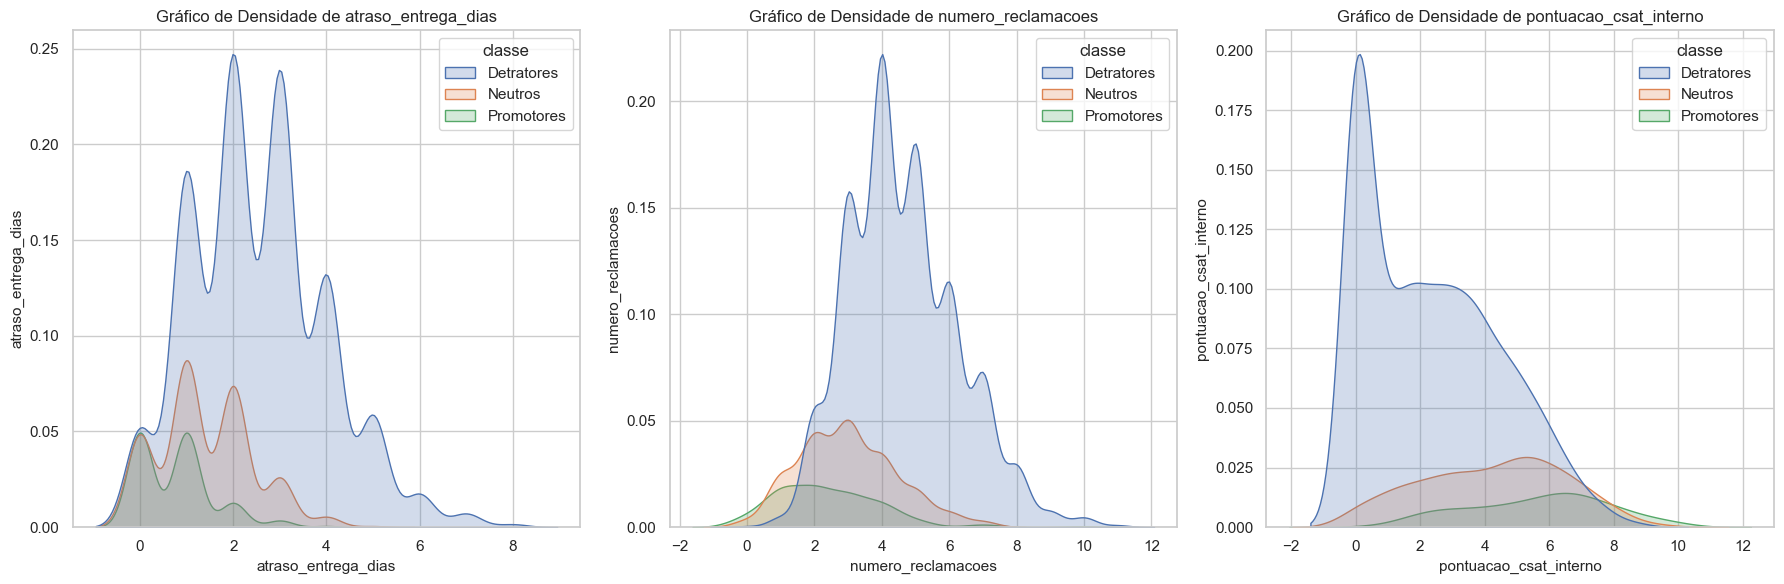

In [30]:
# Visualizando o ViolinPlot e fazendo a comparação dos Detratores
fig, ax = plt.subplots(1, 3, figsize=(18,6))

colunas = ['atraso_entrega_dias', 'numero_reclamacoes', 'pontuacao_csat_interno']

for i, col in enumerate(colunas):
    sns.kdeplot(data=df, x=col, hue='classe', ax=ax[i], fill=True)
    ax[i].set_title(f'Gráfico de Densidade de {col}')
    ax[i].set_ylabel(col)

plt.tight_layout()
plt.show()

## 3.7. Analisando o Ponto de Ruptura

Após identificar os principais fatores associados à satisfação dos clientes, buscamos agora investigar se existe algum **ponto de ruptura na experiência do cliente**. Um ponto de ruptura ocorre quando pequenas mudanças em uma variável resultam em uma mudança significativa na percepção do cliente, aumentando ou reduzindo fortemente a probabilidade de ele se tornar um promotor ou detrator.

Para explorar essa possibilidade, analisamos a relação entre a **pontuação interna de satisfação do cliente (CSAT)** e a classificação do NPS. A variável CSAT foi segmentada em diferentes faixas, permitindo observar como a proporção de **Detratores, Neutros e Promotores** varia conforme o nível de satisfação aumenta.

Essa abordagem permite identificar possíveis **limites críticos na experiência do cliente**, nos quais a percepção do serviço muda de forma mais significativa.

In [31]:
df['CSAT'] = pd.cut(df['pontuacao_csat_interno'],
                    bins=[0., 2., 4., 6., 8., np.inf],
                    labels=['0-2', '2-4', '4-6', '6-8', '8-10'])

df.head()

,idade_cliente,regiao_cliente,tempo_cliente_meses,valor_pedido,quantidade_itens,valor_desconto,parcelas_pagamento,tempo_entrega_dias,atraso_entrega_dias,valor_frete,tentativas_entrega,contatos_atendimento,tempo_resolucao_dias,nps,recompra_30_dias,numero_reclamacoes,pontuacao_csat_interno,classe,CSAT
0,63,Nordeste,14,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5,Neutros,6-8
1,20,Sul,1,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0,Detratores,NaN
2,46,Nordeste,111,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5,Detratores,0-2
3,52,Centro-Oeste,117,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3,Detratores,0-2
4,56,Norte,50,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9,Neutros,6-8


In [32]:
pd.crosstab(df['CSAT'], df['classe'], normalize='index').round(2)

classe,Detratores,Neutros,Promotores
CSAT,,,
0-2,0.84,0.13,0.02
2-4,0.77,0.17,0.06
4-6,0.62,0.28,0.10
6-8,0.36,0.36,0.28
8-10,0.14,0.23,0.63


A análise da relação entre as faixas de CSAT e a classificação do NPS mostra um padrão claro: quanto maior a pontuação de satisfação interna do cliente, menor a proporção de detratores e maior a presença de promotores.

Nas faixas mais baixas de CSAT (0–2 e 2–4), a grande maioria dos clientes é classificada como detratora, indicando experiências fortemente negativas. Conforme a pontuação aumenta, observa-se uma redução progressiva de detratores e um aumento gradual de promotores.

A partir da faixa **6–8**, ocorre uma mudança significativa no comportamento dos clientes, com queda expressiva na proporção de detratores e aumento relevante de promotores. Esse comportamento sugere a existência de um **possível ponto de ruptura na experiência do cliente**, indicando que manter níveis de CSAT acima de aproximadamente 6 pode ser fundamental para melhorar a percepção do serviço e aumentar a probabilidade de recomendação.

## 3.8 Que tipo de Cliente tende a ter NPS mais alto ou mais baixo?

### ● Que tipo de cliente tende a ter NPS mais alto ou mais baixo?

**Resposta:**  
Clientes com NPS mais alto tendem a ter uma experiência mais positiva ao longo da jornada. Em geral, são aqueles que apresentam:

- Menor número de reclamações  
- Pouco ou nenhum atraso na entrega  
- Menor necessidade de contato com o atendimento  
- Maiores níveis de satisfação interna (CSAT)  

Esses fatores indicam uma operação mais eficiente e uma experiência sem atritos, aumentando a chance de o cliente se tornar promotor.

Por outro lado, clientes com NPS mais baixo (detratores) geralmente apresentam:

- Maior número de reclamações  
- Atrasos na entrega  
- Mais interações com o atendimento  
- Baixos níveis de satisfação interna (CSAT)  

Além disso, foi identificado um possível ponto de ruptura relacionado ao CSAT: clientes com pontuação abaixo de aproximadamente 6 tendem a concentrar maior proporção de detratores, enquanto acima desse nível há aumento significativo de promotores.